In [1]:
#import pygeomhpges as hpges
from __future__ import annotations
import sys

import units
import logging
from remage import remage_run
import pygeomtools
import awkward as ak
import numba
import numpy as np
import pint
import pyg4ometry as pg4
import pygeomhpges as hpges
from lgdo import VectorOfVectors
from lgdo.types import LGDO
from numpy.typing import NDArray
from scipy import stats
import subprocess
from numpy import pi
from reboost.units import ureg as u
import surface
import pyg4ometry
from pygeomhpges import make_hpge, draw
import pygeomhpges

import numpy as np
import matplotlib.pyplot as plt

# writing the geometry

In [2]:
reg = pg4.geant4.Registry()
world_s = pg4.geant4.solid.Box("World_s", 400, 400, 400, registry=reg, lunit="mm")
world_l = pg4.geant4.LogicalVolume(world_s, "G4_Galactic", "World_l", registry=reg)
reg.setWorld(world_l)

In [3]:
'''
#Now we create our own argon! We don't need your stupid NIST materials! We prefer doping anyways.

# If we want we can specify the exact isotope composition of our material
argon_36 = pg4.geant4.Isotope(name="Argon36", Z=18, N=36, a=35.97, registry=reg)
argon_38 = pg4.geant4.Isotope(name="Argon38", Z=18, N=38, a=37.97, registry=reg)
argon_40 = pg4.geant4.Isotope(name="Argon40", Z=18, N=40, a=39.97, registry=reg)
argon_element = pg4.geant4.ElementIsotopeMixture(name="Argon", symbol="Ar", n_comp=3, registry=reg)  # sto dicendoc he l'elemento argon è composto da 3 elementi
argon_element.add_isotope(argon_36, 0.00337)
argon_element.add_isotope(argon_38, 0.00063)
argon_element.add_isotope(argon_40, 0.996)

xenon_element = pg4.geant4.ElementSimple(name="Xenon", symbol="Xe", Z=54, A=131.249, registry=reg)
# We need to make a material out of these elements to apply it to a volume.
doped_liquidargon = pg4.geant4.Material(
            name="LiquidArgon",
            density=1.390,  # g/cm3
            number_of_components=2,
            state="liquid",
            temperature=88.8,  # K
            pressure=1.0 * 1e5,  # pascal
            registry=reg,
        )
# We have the option to add by massfraction or by number of atoms (replace "massfraction" with "natoms").
doped_liquidargon.add_element_massfraction("Argon", 0.999)
doped_liquidargon.add_element_massfraction("Xenon", 0.001) # I have no idea how much you usually dope.
'''

'\n#Now we create our own argon! We don\'t need your stupid NIST materials! We prefer doping anyways.\n\n# If we want we can specify the exact isotope composition of our material\nargon_36 = pg4.geant4.Isotope(name="Argon36", Z=18, N=36, a=35.97, registry=reg)\nargon_38 = pg4.geant4.Isotope(name="Argon38", Z=18, N=38, a=37.97, registry=reg)\nargon_40 = pg4.geant4.Isotope(name="Argon40", Z=18, N=40, a=39.97, registry=reg)\nargon_element = pg4.geant4.ElementIsotopeMixture(name="Argon", symbol="Ar", n_comp=3, registry=reg)  # sto dicendoc he l\'elemento argon è composto da 3 elementi\nargon_element.add_isotope(argon_36, 0.00337)\nargon_element.add_isotope(argon_38, 0.00063)\nargon_element.add_isotope(argon_40, 0.996)\n\nxenon_element = pg4.geant4.ElementSimple(name="Xenon", symbol="Xe", Z=54, A=131.249, registry=reg)\n# We need to make a material out of these elements to apply it to a volume.\ndoped_liquidargon = pg4.geant4.Material(\n            name="LiquidArgon",\n            density=1

In [4]:
# let's start with a liquid argon balloon
# For a solid orb we specify the name and radius (and the registry of course).
lar_s = pg4.geant4.solid.Orb("LAr_s", 150, registry=reg, lunit="mm")
lar_l = pg4.geant4.LogicalVolume(lar_s, "G4_lAr", "LAr_l", registry=reg)
lar_pv =pg4.geant4.PhysicalVolume([0, 0, 0], [0, 0, 0], lar_l, "LAr", world_l, registry=reg)

In [5]:
source_s = pg4.geant4.solid.Tubs("Source_s", 0, 1, 1, 0, 2 * pi, registry=reg)
source_l = pg4.geant4.LogicalVolume(source_s, "G4_BRAIN_ICRP", "Source_L", registry=reg)


In [6]:
pg4.geant4.PhysicalVolume(
    [0, 0, 0], [0, 0, 0, "cm"], source_l, "Source", lar_l, registry=reg
)

Physical Volume : Source Rotation : Source_rot = [expr_rot_x_Source_rot : 0.000000000000000 expr_rot_y_Source_rot : 0.000000000000000 expr_rot_z_Source_rot : 0.000000000000000] Position : Source_pos = [expr_pos_x_Source_pos : 0.000000000000000 expr_pos_y_Source_pos : 0.000000000000000 expr_pos_z_Source_pos : 0.000000000000000]

In [7]:
# We have two different detectors, Corgi and Bob. Although Bob doesnt seem very happy for some reason...
bege_meta = {
    "name": "bege_hpge",
    "type": "bege",
    "production": {
        "enrichment": {"val": 0.855, "unc": 0.015},
    },
    "geometry": {
        "height_in_mm": 30,
        "radius_in_mm": 37,
        "borehole": {"radius_in_mm": 6.75, "depth_in_mm": 25},
        "groove": {"depth_in_mm": 2.0, "radius_in_mm": {"outer": 10.5, "inner": 7.5}},
        "pp_contact": {"radius_in_mm": 7.5, "depth_in_mm": 0},
        "taper": {
            "top": {"angle_in_deg": 0.0, "height_in_mm": 0.0},
            "bottom": {"angle_in_deg": 0.0, "height_in_mm": 0.0},
            "borehole": {"angle_in_deg": 0, "height_in_mm": 0},
        },
    },
}


In [8]:
bob_l = hpges.make_hpge(bege_meta, name="Bob_L", registry=reg)
# We shift them a little bit so they do not overlap! That would again be a malformed geometry.
bob_pv = pg4.geant4.PhysicalVolume(
    [0, 0, 0], [-5, 0, -3, "cm"], bob_l, "Bob", lar_l, registry=reg
)

In [9]:
bob_pv.set_pygeom_active_detector(
    pygeomtools.RemageDetectorInfo("germanium", 1, bege_meta)
)

In [10]:
# Write the geometry file if you do not have x-support for visualization
lar_l.pygeom_color_rgba = (0, 0, 1, 0.1)
bob_l.pygeom_color_rgba = (0.6, 0, 0.8, 0.6)



In [11]:
# FONDAMENTTALE : DEVI CREARE IL REGISTRO
reg.detector_aux = None
pygeomtools.write_pygeom(reg, "geometry.gdml")

In [12]:
macro_content = [
"/RMG/Manager/Logging/LogLevel summary",
"/RMG/Processes/HadronicPhysics Shielding", # This activates hadronic physics, necessary for the radioactive source
"/RMG/Geometry/RegisterDetectorsFromGDML Germanium",
"/RMG/Output/NtupleUseVolumeName true",
"/run/initialize",  
#"/RMG/Output/Germanium/DiscardPhotonsIfNoGermaniumEdep true",
#"/RMG/Processes/Stepping/ResetInitialDecayTime true",
"/RMG/Generator/Confine Volume",
"/RMG/Generator/Confinement/Physical/AddVolume Source", # Confine primaries to this volume
"/RMG/Generator/Select GPS",
"/gps/particle     ion",
#"/gps/ion           88 224",
"/gps/ion           95 241",  # per americio
"/gps/energy       0 keV",
#"/process/had/rdm/nucleusLimits 208 224 81 88",   
"/process/had/rdm/nucleusLimits 241 241 95 95",  #èer americio
"/run/beamOn 1000000", # run 50000 events
]


In [16]:
macro_content = [
"/RMG/Manager/Logging/LogLevel summary",
"/RMG/Processes/HadronicPhysics Shielding",
"/RMG/Geometry/RegisterDetectorsFromGDML Germanium",
"/RMG/Output/NtupleUseVolumeName true",
"/run/initialize",
"/RMG/Generator/Confine Volume",
"/RMG/Generator/Confinement/Physical/AddVolume Source",
"/RMG/Processes/Stepping/ResetInitialDecayTime true",
"/RMG/Generator/Select GPS",
"/gps/particle ion",
"/gps/ion 56 133",
"/gps/energy 0 keV",
"/process/had/rdm/nucleusLimits 133 133 56 56",
"/run/beamOn 1000000",  
]

In [17]:
try:
    # Run remage
    remage_run(macros=macro_content,
              gdml_files="geometry.gdml",
              output="out.lh5",
              overwrite_output=True
              )
except Exception as e:
    # Catch any error that remage_run might raise
    print(f"❌ Simulation failed: {e}")

  _ __ ___ _ __ ___   __ _  __ _  ___ 
 | '__/ _ \ '_ ` _ \ / _` |/ _` |/ _ \
 | | |  __/ | | | | | (_| | (_| |  __/ v0.24.0
 |_|  \___|_| |_| |_|\__,_|\__, |\___| using geant4-11-04 [MT]
                           |___/      

G4GDML: Reading 'geometry.gdml'...
G4GDML: Reading definitions...
G4GDML: Reading materials...
G4GDML: Reading solids...
G4GDML: Reading structure...
G4GDML: Reading userinfo...
G4GDML: Reading setup...
G4GDML: Reading 'geometry.gdml' done!
Stripping off GDML names of materials, solids and volumes ...


[Summary -> CLHEP::HepRandom seed changed to: 1815429517 (from system entropy)
[Summary -> Checking for overlaps in GDML geometry...
[Summary -> Opening output file: .rmg-tmp-51673.out.hdf5 (for out.lh5)
[Summary -> Starting run nr. 0. Current local time is 06-07-2026 07:08:30 PDT
[Summary -> Number of events to be processed: 1000000
[Summary -> Processing event nr. 100000 (10%), at 0 days, 0 hours, 0 minutes and 25 seconds
[Summary -> Processing event nr. 200000 (20%), at 0 days, 0 hours, 0 minutes and 50 seconds
[Summary -> Processing event nr. 300000 (30%), at 0 days, 0 hours, 1 minutes and 15 seconds
[Summary -> Processing event nr. 400000 (40%), at 0 days, 0 hours, 1 minutes and 40 seconds
[Summary -> Processing event nr. 500000 (50%), at 0 days, 0 hours, 2 minutes and 6 seconds
[Summary -> Processing event nr. 600000 (60%), at 0 days, 0 hours, 2 minutes and 30 seconds
[Summary -> Processing event nr. 700000 (70%), at 0 days, 0 hours, 2 minutes and 55 seconds
[Summary -> Processin

# post processing

In [18]:
import lh5
import awkward as ak
import hist
import matplotlib.pyplot as plt

In [19]:
# This just runs the command line command lh5ls to investigate the data structure
!lh5ls out.lh5

/
├── detector_origins · struct{Bob} 
│   └── Bob · struct{xloc,yloc,zloc} 
│       ├── xloc · real 
│       ├── yloc · real 
│       └── zloc · real 
├── number_of_simulated_events · real 
├── stp · struct{Bob} 
│   ├── Bob · table{dist_to_surf,edep,evtid,particle,t0,time,xloc,yloc,zloc} 
│   │   ├── dist_to_surf · array<1>{array<1>{real}} 
│   │   │   ├── cumulative_length · array<1>{real} 
│   │   │   └── flattened_data · array<1>{real} 
│   │   ├── edep · array<1>{array<1>{real}} 
│   │   │   ├── cumulative_length · array<1>{real} 
│   │   │   └── flattened_data · array<1>{real} 
│   │   ├── evtid · array<1>{real} 
│   │   ├── particle · array<1>{array<1>{real}} 
│   │   │   ├── cumulative_length · array<1>{real} 
│   │   │   └── flattened_data · array<1>{real} 
│   │   ├── t0 · array<1>{real} 
│   │   ├── time · array<1>{array<1>{real}} 
│   │   │   ├── cumulative_length · array<1>{real} 
│   │   │   └── flattened_data · array<1>{real} 
│   │   ├── xloc · array<1>{array<1>{real}} 

In [20]:
data = lh5.read_as("/stp/Bob", "out.lh5", "ak")

In [21]:
print(f"Type of data: {ak.type(data)}")
print(f"Fields of data: {data.fields}")

Type of data: 164177 * {dist_to_surf: var * float64, edep: var * float64, evtid: int64, particle: var * int32, t0: float64, time: var * float64, xloc: var * float64, yloc: var * float64, zloc: var * float64}
Fields of data: ['dist_to_surf', 'edep', 'evtid', 'particle', 't0', 'time', 'xloc', 'yloc', 'zloc']


In [22]:
print(f"Energy field shape: {ak.type(data.edep)}")
print(f"Energy field: {data.edep}")
print(f"Event id field: {data.evtid}")

Energy field shape: 164177 * var * float64
Energy field: [[0.116, 30.1, 0.0952, 1, 0.0161, ..., 0.0486, 0.026, 0.0171, 0.0171], ...]
Event id field: [5, 6, 23, 35, 52, 61, 62, ..., 999974, 999976, 999984, 999987, 999991, 999999]


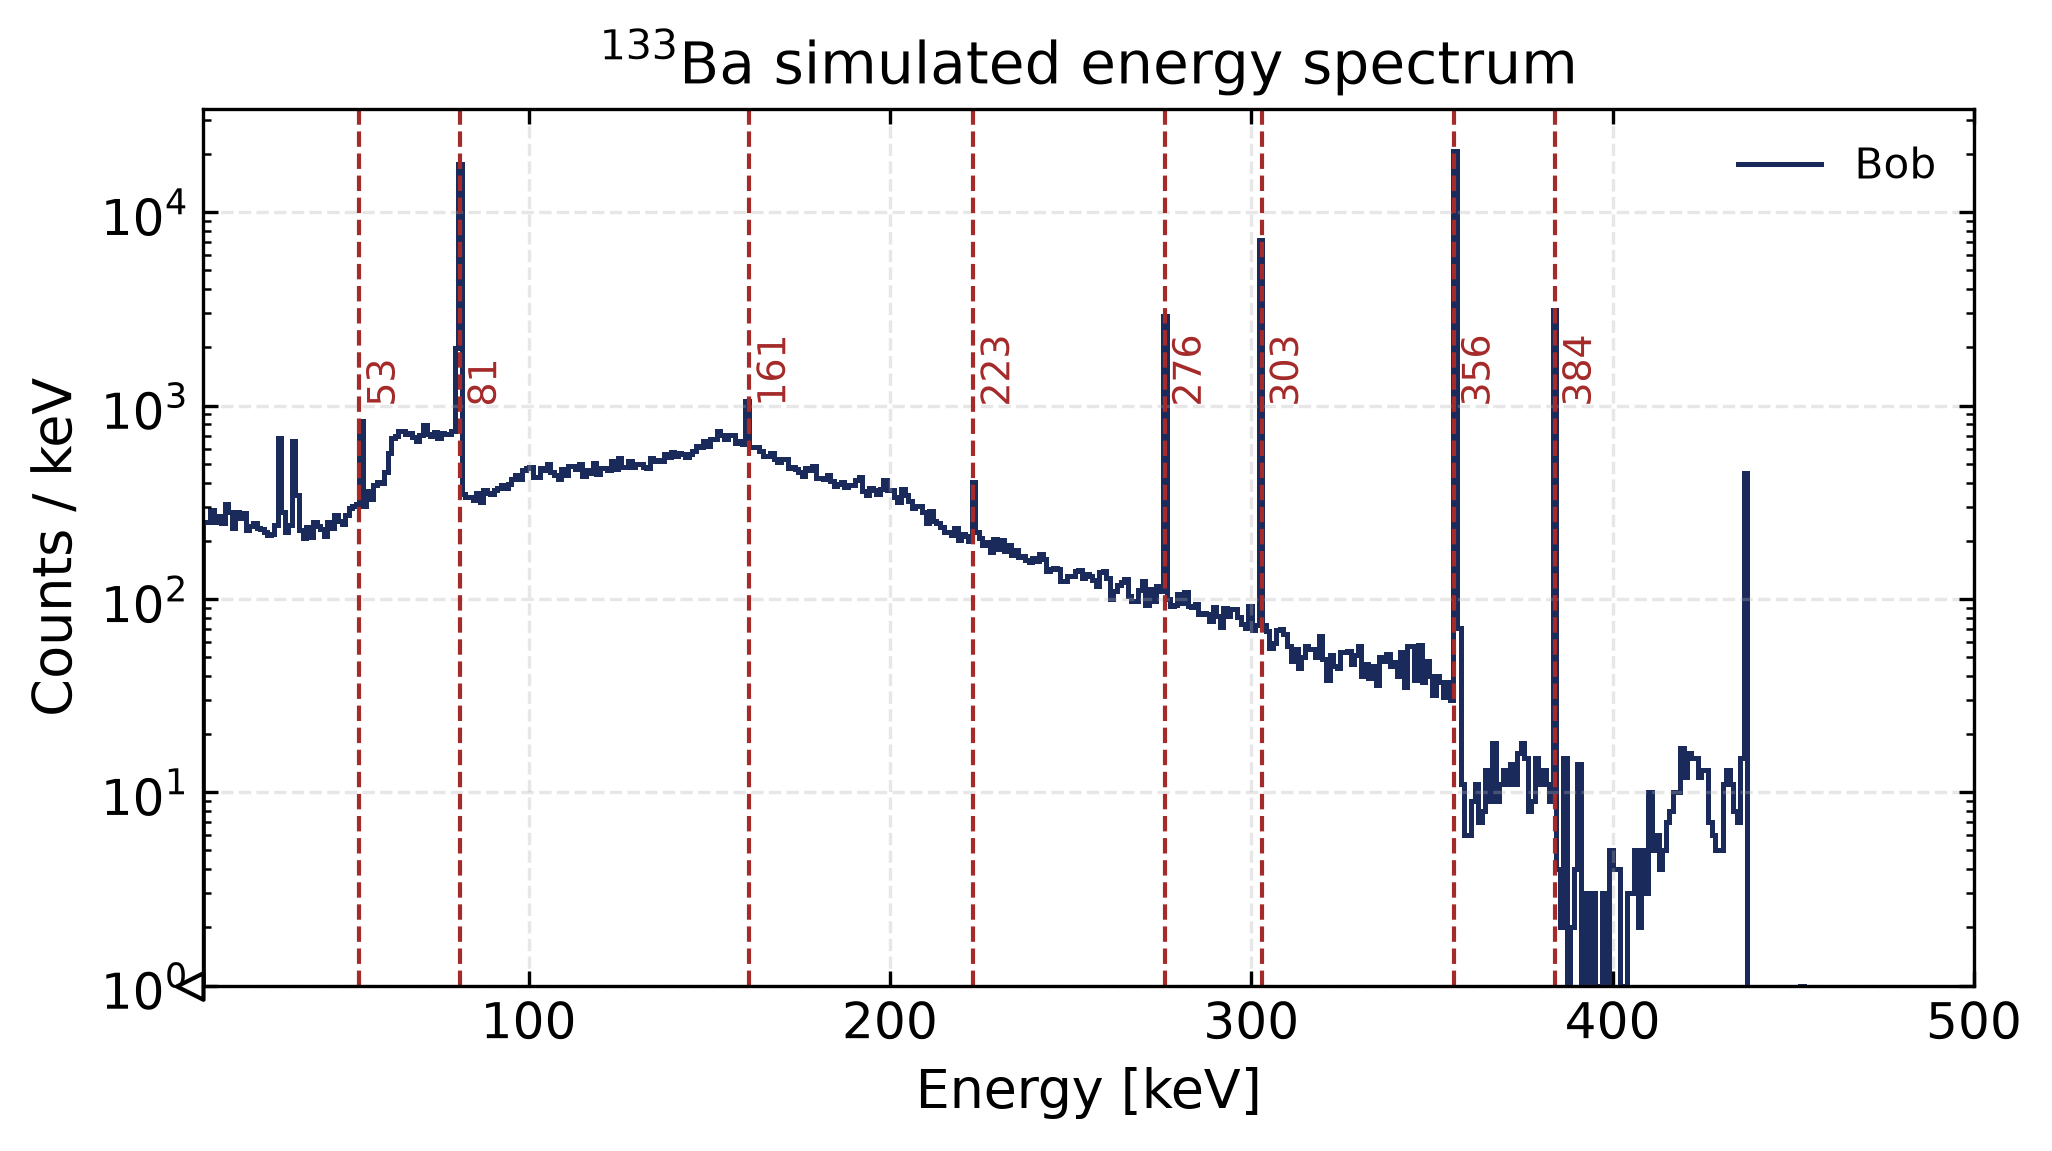

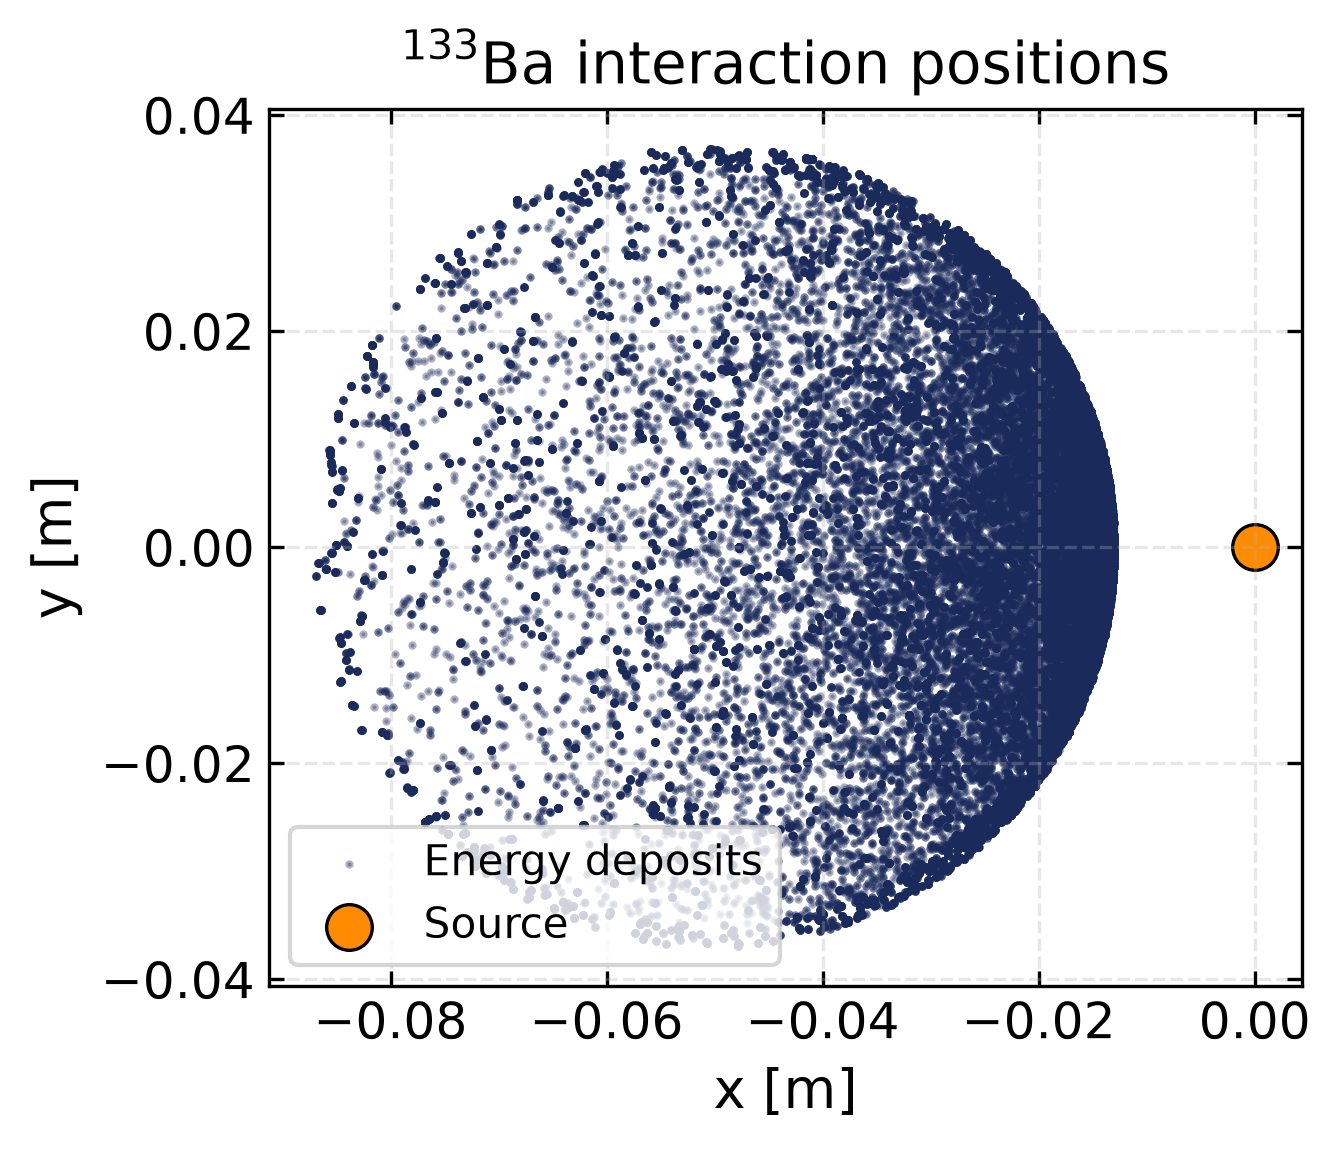

In [52]:
plt.style.use("default")

plt.rcParams.update({
    "figure.figsize": (7, 4),
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
})

# ------------------
# Energy spectrum
# ------------------

fig, ax = plt.subplots(dpi = 300)

def plot_edep(detid):
    data = lh5.read_as(f"stp/{detid}", "out.lh5", "ak")

    (
        hist.new
        .Reg(500, 10, 500, name="Energy [keV]")
        .Double()
        .fill(ak.sum(data.edep, axis=-1))
        .plot(
            ax=ax,
            yerr=False,
            histtype="step",
            color="#1A2A5B",
            #edgecolor="#1A2A5B",
            linewidth=1.2,
            label=detid,
        )
    )

plot_edep("Bob")

gamma_lines = {
    53: "53",
    81: "81",
    161: "161",
    223: "223",
    276: "276",
    303: "303",
    356: "356",
    384: "384",
}

for E, label in gamma_lines.items():
    ax.axvline(E, color="brown", ls="--", lw=1)
    ax.text(
        E + 2,
        11e2,
        label,
        rotation=90,
        color="brown",
        fontsize=9,
    )

ax.set_yscale("log")
ax.set_xlim(10, 500)
ax.set_ylim(1, None)

ax.set_xlabel("Energy [keV]")
ax.set_ylabel("Counts / keV")
ax.set_title(r"$^{133}$Ba simulated energy spectrum")

ax.legend(frameon=False)

plt.tight_layout()


# ------------------
# Hit positions
# ------------------

fig, ax = plt.subplots(figsize=(7, 4), dpi=300)

def plot_hits(detid):
    data = lh5.read_as(f"stp/{detid}", "out.lh5", "ak")[:10_000]

    ax.scatter(
        ak.flatten(data.xloc),
        ak.flatten(data.yloc),
        s=1,
        alpha=0.35,
        color="#1A2A5B",
        rasterized=True,
        label="Energy deposits",
    )

plot_hits("Bob")

ax.scatter(
    0,
    0,
    s=120,
    color="darkorange",
    edgecolor="black",
    linewidth=0.8,
    label="Source",
)

ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title(r"$^{133}$Ba interaction positions")
ax.set_aspect("equal")
ax.legend()

plt.tight_layout()
plt.show()

# Reboost

In [53]:
import reboost
import numpy as np
from reboost import hpge
from reboost.hpge import surface, psd
from reboost.shape import group
from reboost.math import functions
from reboost.math.stats import gaussian_sample


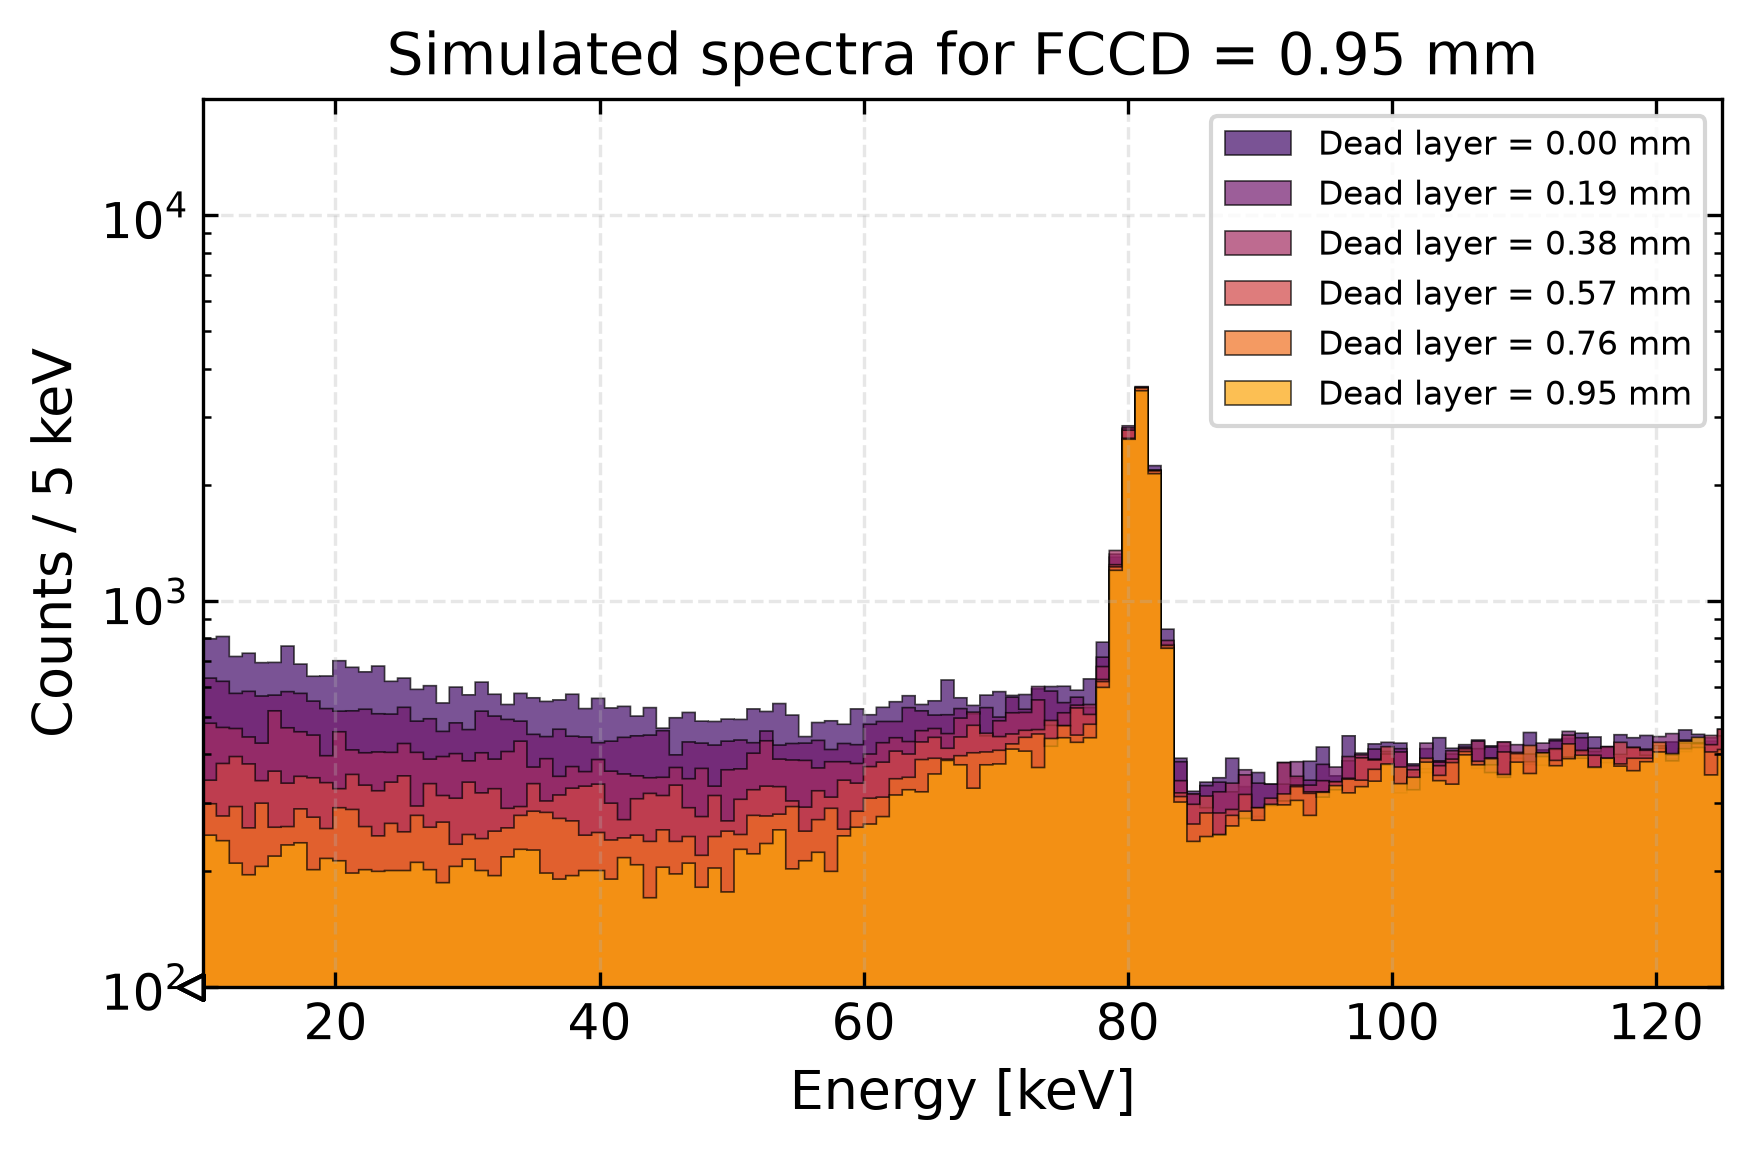

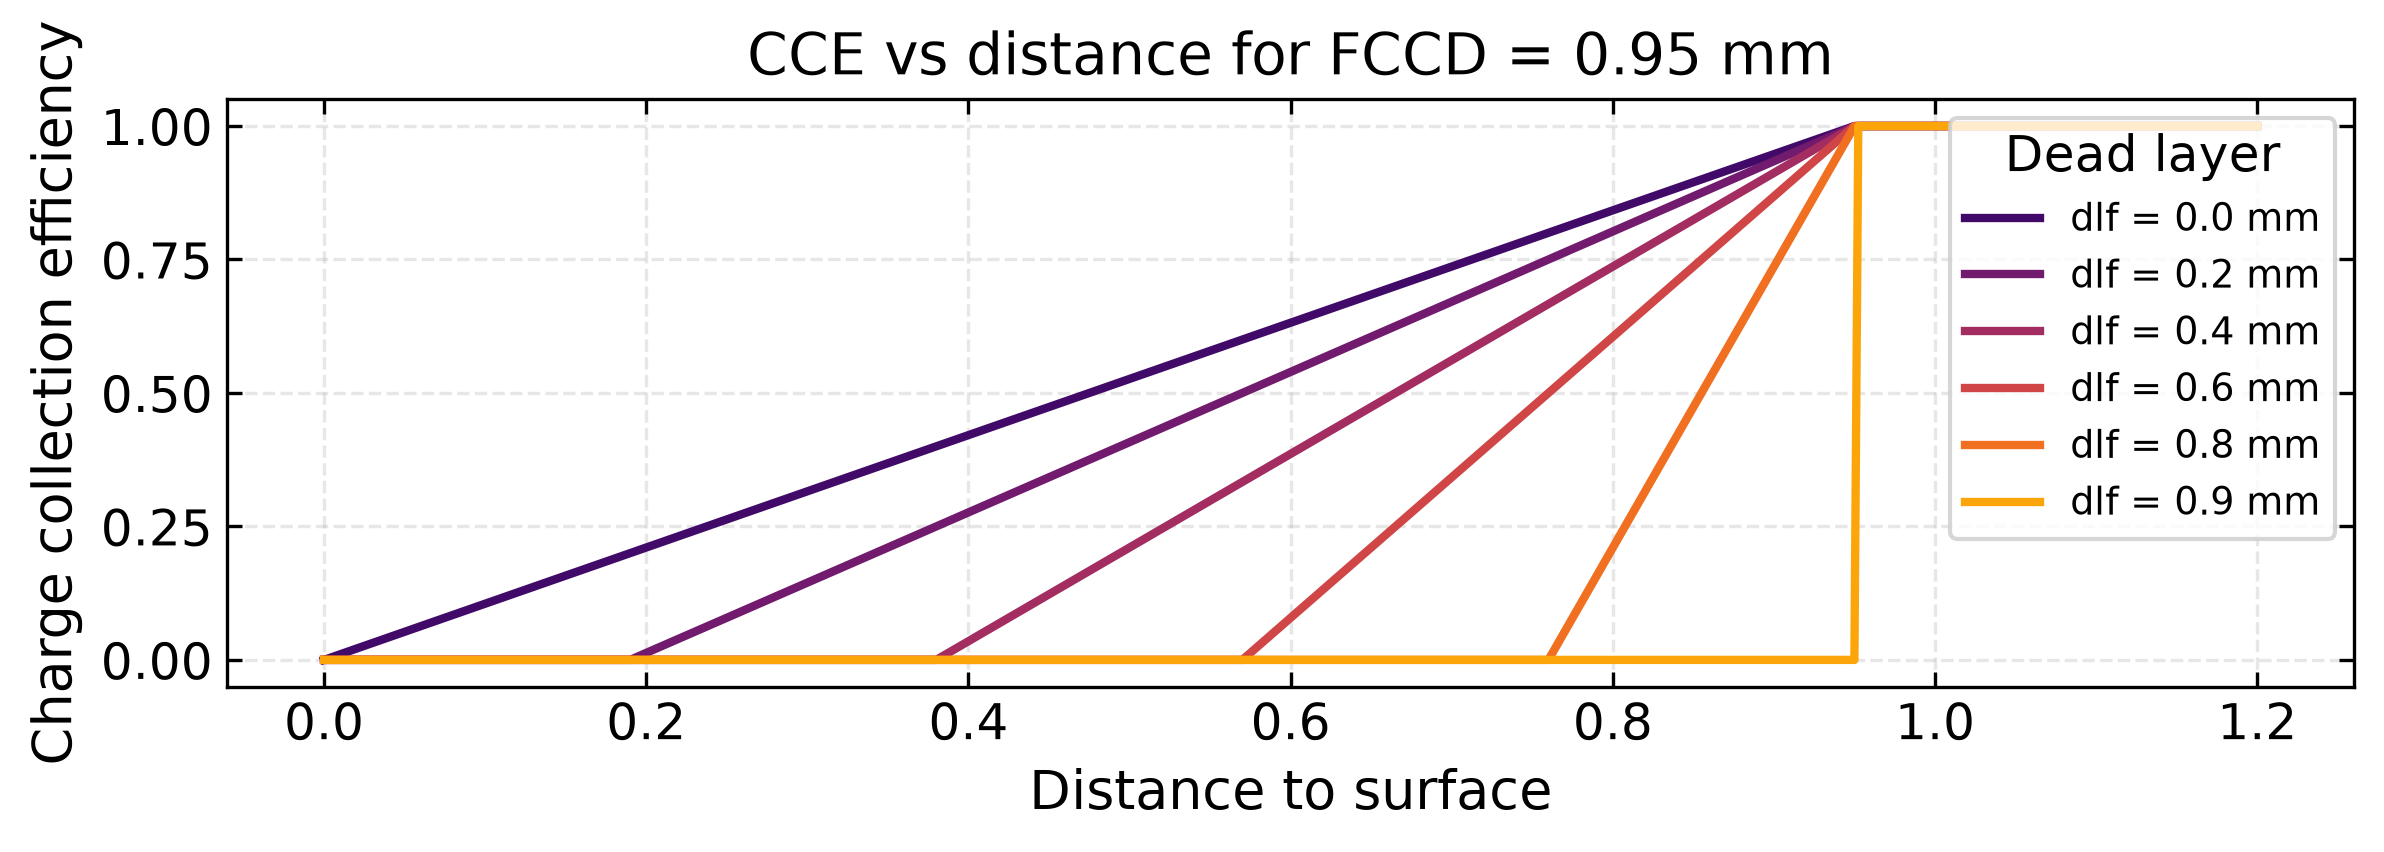

In [87]:
# -----------------------------
# Spectrum plot
# -----------------------------
def plot_edep_reboost_deadlayer(detid, dlf, color=None, ax=None):
    if ax is None:
        ax = plt.gca()

    data = lh5.read_as(f"stp/{detid}", "out.lh5", "ak", with_units=True)

    fccd_in_mm = 0.95

    charge_collection_eff = reboost.math.functions.piecewise_linear_activeness(
        data.dist_to_surf,
        fccd_in_mm=fccd_in_mm,
        dlf=dlf,
    )

    energy = ak.sum(data.edep * charge_collection_eff, axis=-1)
    #energy = ak.sum(data.edep * 1, axis=-1)
    energy_smeared = reboost.math.stats.gaussian_sample(
        energy,
        sigma=1,)
    

    (
        hist.new
        .Reg(500, 10, 500, name="Energy [keV]")
        .Double()
        .fill(energy_smeared)
        .plot(
            ax=ax,
            yerr=False,
            histtype="fill",
            alpha=0.7,
            color=color,
            edgecolor="black",
            linewidth=0.4,
            label=f"Dead layer = {fccd_in_mm * dlf:.2f} mm",
        )
    )


# -----------------------------
# CCE function
# -----------------------------
def plot_cce(dlf, color, ax=None):
    if ax is None:
        ax = plt.gca()

    x = np.linspace(0, 1.2, 500)
    fccd_in_mm= 0.95
    y = reboost.math.functions.piecewise_linear_activeness(
        x,
        fccd_in_mm=fccd_in_mm,
        dlf=dlf,
    )

    ax.plot(
        x,
        y,
        color=color,
        lw=2,
        label=f"dlf = {fccd_in_mm*dlf:.1f} mm",
    )


# -------------------------------
# Plot spectra
# -------------------------------
fig, ax = plt.subplots(figsize=(6, 4), dpi = 300)

dlfs = np.arange(0, 1.2, 0.2)
colors = plt.colormaps["inferno"](np.linspace(0.2, 0.8, len(dlfs)))

for dlf, color in zip(dlfs, colors):
    plot_edep_reboost_deadlayer(
        "Bob",
        dlf=dlf,
        color=color,
        ax=ax)
    
#plot_edep("Bob")
ax.set_yscale("log")
ax.set_xlim(10, 125)
ax.set_ylim(100, 20000)

ax.set_xlabel("Energy [keV]")
ax.set_ylabel("Counts / 5 keV")
ax.set_title("Simulated spectra for FCCD = 0.95 mm")

ax.grid(alpha=0.3)
ax.legend( fontsize=8, loc = "upper right")

plt.tight_layout()
plt.show()


# -------------------------------
# Plot CCE curves (NEW FIGURE)
# -------------------------------
fig2, ax2 = plt.subplots(figsize=(8, 3), dpi = 300)

for dlf, color in zip(dlfs, colors):
    plot_cce(
        dlf=dlf,
        color=color,
        ax=ax2,
    )

ax2.set_xlabel("Distance to surface")
ax2.set_ylabel("Charge collection efficiency")
ax2.set_title("CCE vs distance for FCCD = 0.95 mm")

ax2.grid(alpha=0.3)
ax2.legend(title="Dead layer", fontsize=9., loc = "upper right")

plt.tight_layout()
plt.show()

## energy deposition


In [34]:
reg = pyg4ometry.gdml.Reader("geometry.gdml").getRegistry()
hpge_pyobj = hpges.make_hpge(bege_meta, registry=None)
position = reg.physicalVolumeDict["Bob"].position.eval()

In [35]:
print(reg.physicalVolumeDict.keys())

dict_keys(['Source', 'Bob', 'LAr'])


In [36]:
stp = lh5.read_as("stp/Bob", "out.lh5", "ak", with_units=True)

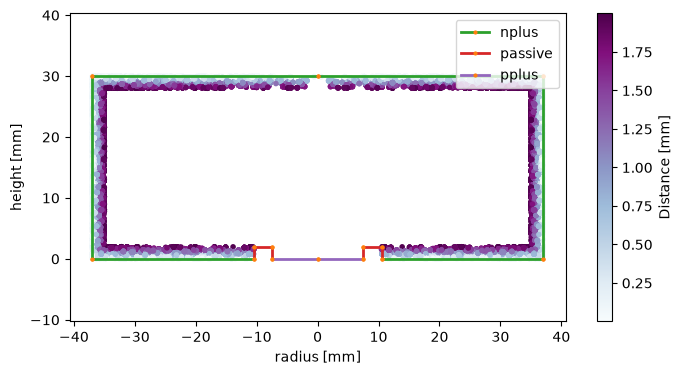

In [37]:
# extract r and z
dist_all = reboost.hpge.surface.distance_to_surface(
    stp.xloc, stp.yloc, stp.zloc, hpge_pyobj, position
)

dist_nplus = reboost.hpge.surface.distance_to_surface(
    stp.xloc,
    stp.yloc,
    stp.zloc,
    hpge_pyobj,
    position,
    surface_type="nplus",
)
r = ak.flatten(
    np.sqrt((stp.xloc * 1000 - position[0]) ** 2 + (stp.yloc * 1000 - position[1]) ** 2)
)
z = ak.flatten(stp.zloc * 1000 - position[2])
rng = np.random.default_rng()
r = rng.choice([-1, 1], p=[0.5, 0.5], size=len(r)) * r

# make the plot
fig, ax = plt.subplots(figsize=(8, 4))
pygeomhpges.draw.plot_profile(hpge_pyobj, axes=ax, split_by_type=True)

cut = ak.flatten(dist_nplus) < 2
s = ax.scatter(
    r[cut],
    z[cut],
    c=ak.flatten(dist_nplus)[cut],
    marker=".",
    cmap="BuPu",
)
c = plt.colorbar(s)

# configure the plot
ax.axis("equal")
c.set_label("Distance [mm]")
_ = ax.set_xlabel("radius [mm]")
_ = ax.set_ylabel("height [mm]")